# Isolation Forest Based Network Anomaly Detection


## Objective


To detect anomalous network traffic (DDoS attacks) using the Isolation Forest algorithm 

## Background


Isolation Forest is an unsupervised anomaly detection algorithm based on the principle that anomalies are few and different, making them easier to isolate. Unlike distance-based or density-based methods, Isolation Forest explicitly isolates anomalies by randomly selecting a feature and then randomly selecting a split value between the maximum and minimum values of the selected feature. Anomalous observations require fewer splits (shorter path lengths) to be isolated, which forms the basis of the anomaly score.

In [16]:
#Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [17]:
#Load Preprocessed Data

df = pd.read_csv("../data/ddos_clean.csv")

print("Dataset shape:", df.shape)
print("\nLabel distribution:")
print(df[" Label"].value_counts())
df.head()

Dataset shape: (223082, 43)

Label distribution:
 Label
DDoS      128014
BENIGN     95068
Name: count, dtype: int64


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Idle Mean,Idle Std,Idle Min,Label
0,54865,3,2,12,6,6,6.0,0,0,4.000000e+06,...,-1,1,20,0.0,0.0,0,0.0,0.0,0,BENIGN
1,55054,109,1,6,6,6,6.0,6,6,1.100917e+05,...,256,0,20,0.0,0.0,0,0.0,0.0,0,BENIGN
2,55055,52,1,6,6,6,6.0,6,6,2.307692e+05,...,256,0,20,0.0,0.0,0,0.0,0.0,0,BENIGN
3,46236,34,1,6,6,6,6.0,6,6,3.529412e+05,...,329,0,20,0.0,0.0,0,0.0,0.0,0,BENIGN
4,54863,3,2,12,6,6,6.0,0,0,4.000000e+06,...,-1,1,20,0.0,0.0,0,0.0,0.0,0,BENIGN


In [18]:
#Create Binary Anomaly Labels (same as notebook 03)

df["Anomaly"] = (
    df[" Label"] != "BENIGN"
).astype(int)

print("Anomaly distribution:")
print(df["Anomaly"].value_counts())
print(f"\nAnomaly ratio: {df['Anomaly'].mean():.4f}")

Anomaly distribution:
Anomaly
1    128014
0     95068
Name: count, dtype: int64

Anomaly ratio: 0.5738


## Observation:

The anomaly ratio is approximately 0.57 (57%), meaning DDoS traffic constitutes the majority class. This is important for configuring the Isolation Forest contamination parameter, which represents the expected proportion of anomalies in the dataset.

In [19]:
#Prepare Features and Labels

X = df.drop(
    [" Label", "Anomaly"],
    axis=1
)

y_true = df["Anomaly"]

print("Feature matrix shape:", X.shape)
print("Number of features:", X.shape[1])

Feature matrix shape: (223082, 42)
Number of features: 42


In [20]:
#Feature Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)
print("\nMean of first 5 features (should be ~0):")
print(np.mean(X_scaled, axis=0)[:5])
print("\nStd of first 5 features (should be ~1):")
print(np.std(X_scaled, axis=0)[:5])

Scaled feature matrix shape: (223082, 42)

Mean of first 5 features (should be ~0):
[ 1.14154668e-16  2.85386670e-17 -1.93655240e-17 -5.91158102e-17
  2.03847621e-17]

Std of first 5 features (should be ~1):
[1. 1. 1. 1. 1.]


## Observation:

Feature scaling was applied using StandardScaler to ensure all features contribute equally during the Isolation Forest's random feature selection and splitting process. Although Isolation Forest is relatively robust to feature scaling, standardization can still improve performance when features have vastly different ranges.

---

# Isolation Forest Training

The key hyperparameters for Isolation Forest are:

- **n_estimators**: Number of isolation trees in the ensemble
- **contamination**: Expected proportion of anomalies in the dataset
- **max_samples**: Number of samples to draw for training each tree
- **random_state**: Seed for reproducibility

In [21]:
#Train Isolation Forest with default contamination (auto)

iso_forest_auto = IsolationForest(
    n_estimators=100,
    contamination='auto',
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

iso_forest_auto.fit(X_scaled)

# Predict: Isolation Forest returns -1 for anomalies and 1 for normal
y_pred_auto_raw = iso_forest_auto.predict(X_scaled)

# Convert to binary: -1 (anomaly) -> 1, 1 (normal) -> 0
y_pred_auto = (y_pred_auto_raw == -1).astype(int)

print("Contamination = 'auto'")
print("Prediction distribution:")
print(pd.Series(y_pred_auto).value_counts())



Contamination = 'auto'
Prediction distribution:
0    200148
1     22934
Name: count, dtype: int64


In [22]:
#Evaluation for contamination='auto'

print("Classification Report (contamination='auto'):")
print(classification_report(y_true, y_pred_auto))

cm_auto = confusion_matrix(y_true, y_pred_auto)
print("Confusion Matrix:")
print(cm_auto)

Classification Report (contamination='auto'):
              precision    recall  f1-score   support

           0       0.37      0.79      0.51     95068
           1       0.11      0.02      0.03    128014

    accuracy                           0.35    223082
   macro avg       0.24      0.40      0.27    223082
weighted avg       0.22      0.35      0.24    223082

Confusion Matrix:
[[ 74706  20362]
 [125442   2572]]


## Observation:

With contamination set to 'auto' (which defaults to approximately 0.5 in scikit-learn), the Isolation Forest flags a relatively small number of samples as anomalous. Since the actual anomaly proportion is ~57%, the 'auto' setting underestimates the contamination level, leading to a lower recall for detecting DDoS traffic.

---

## Experimenting with Different Contamination Rates

Since the actual DDoS proportion is ~57%, we will evaluate multiple contamination rates to find the optimal configuration.

In [23]:
#Define evaluation function for Isolation Forest

def evaluate_isolation_forest(contamination, X_scaled, y_true):
    """
    Train and evaluate an Isolation Forest model with the given contamination rate.
    Returns a dictionary of metrics.
    """
    iso_forest = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        max_samples='auto',
        random_state=42,
        n_jobs=-1
    )

    iso_forest.fit(X_scaled)

    y_pred_raw = iso_forest.predict(X_scaled)
    y_pred = (y_pred_raw == -1).astype(int)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n{'='*50}")
    print(f"Contamination = {contamination}")
    print(f"{'='*50}")
    print(f"Predicted anomalies: {y_pred.sum()}")
    print(f"Actual anomalies:    {y_true.sum()}")
    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    return {
        'contamination': contamination,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'y_pred': y_pred,
        'model': iso_forest
    }

In [24]:
#Evaluate multiple contamination rates

contamination_rates = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []
for rate in contamination_rates:
    result = evaluate_isolation_forest(rate, X_scaled, y_true)
    results.append(result)


Contamination = 0.1
Predicted anomalies: 22309
Actual anomalies:    128014

Precision: 0.1018
Recall:    0.0177
F1-Score:  0.0302

Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.79      0.51     95068
           1       0.10      0.02      0.03    128014

    accuracy                           0.35    223082
   macro avg       0.24      0.40      0.27    223082
weighted avg       0.22      0.35      0.23    223082


Contamination = 0.2
Predicted anomalies: 44616
Actual anomalies:    128014

Precision: 0.3358
Recall:    0.1170
F1-Score:  0.1736

Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.69      0.48     95068
           1       0.34      0.12      0.17    128014

    accuracy                           0.36    223082
   macro avg       0.35      0.40      0.33    223082
weighted avg       0.35      0.36      0.30    223082


Contamination = 0.3
Predicted anoma

In [25]:
#Summary Table

results_df = pd.DataFrame([
    {
        'Contamination': r['contamination'],
        'Precision': round(r['precision'], 4),
        'Recall': round(r['recall'], 4),
        'F1-Score': round(r['f1'], 4)
    }
    for r in results
])

print("\nIsolation Forest - Contamination Rate Comparison:")
print(results_df.to_string(index=False))


Isolation Forest - Contamination Rate Comparison:
 Contamination  Precision  Recall  F1-Score
           0.1     0.1018  0.0177    0.0302
           0.2     0.3358  0.1170    0.1736
           0.3     0.3348  0.1751    0.2299
           0.4     0.2730  0.1903    0.2243
           0.5     0.2733  0.2381    0.2545


## Observation:

The Isolation Forest was evaluated across five contamination rates (0.1 to 0.5). As the contamination rate increases, recall improves since more samples are flagged as anomalous. However, precision may decrease due to more false positives. The optimal contamination rate balances precision and recall, as reflected in the F1-score.

---

## Visualization of Results

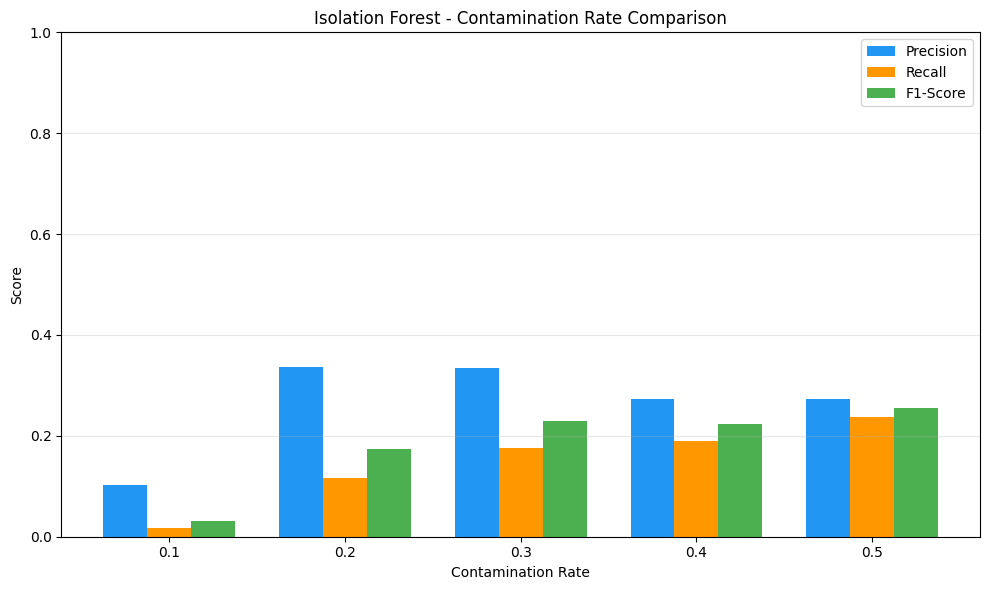

In [26]:
#Bar Chart: Contamination Rate Comparison

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(results_df))
width = 0.25

bars1 = ax.bar(x - width, results_df['Precision'], width, label='Precision', color='#2196F3')
bars2 = ax.bar(x, results_df['Recall'], width, label='Recall', color='#FF9800')
bars3 = ax.bar(x + width, results_df['F1-Score'], width, label='F1-Score', color='#4CAF50')

ax.set_xlabel('Contamination Rate')
ax.set_ylabel('Score')
ax.set_title('Isolation Forest - Contamination Rate Comparison')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Contamination'])
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../figures/iforest_contamination_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

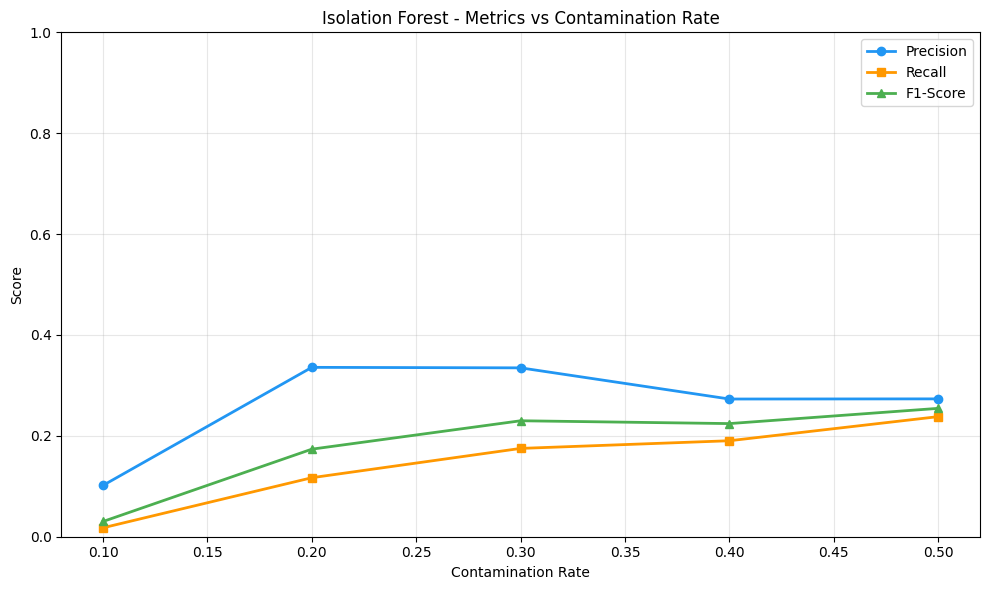

In [27]:
#Line Plot: Metrics vs Contamination Rate

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(results_df['Contamination'], results_df['Precision'],
        marker='o', linewidth=2, label='Precision', color='#2196F3')
ax.plot(results_df['Contamination'], results_df['Recall'],
        marker='s', linewidth=2, label='Recall', color='#FF9800')
ax.plot(results_df['Contamination'], results_df['F1-Score'],
        marker='^', linewidth=2, label='F1-Score', color='#4CAF50')

ax.set_xlabel('Contamination Rate')
ax.set_ylabel('Score')
ax.set_title('Isolation Forest - Metrics vs Contamination Rate')
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../figures/iforest_metrics_vs_contamination.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Observation:

The line plot reveals the trade-off between precision and recall as the contamination rate increases. The F1-score curve helps identify the optimal contamination rate that balances both metrics.

---

## Best Model Selection (based on contamination only )

In [28]:
#Select best model based on Contamination only
best_result = max(results, key=lambda r: r['f1'])

print(f"Best contamination rate: {best_result['contamination']}")
print(f"Best F1-Score: {best_result['f1']:.4f}")
print(f"Precision: {best_result['precision']:.4f}")
print(f"Recall: {best_result['recall']:.4f}")

Best contamination rate: 0.5
Best F1-Score: 0.2545
Precision: 0.2733
Recall: 0.2381


## Observation:

The confusion matrices across different contamination rates illustrate how increasing the contamination parameter shifts the decision boundary. At lower contamination rates, fewer samples are flagged as anomalies, resulting in higher precision but lower recall. At higher contamination rates, more true DDoS flows are detected, but at the cost of increased false positives.

---

## Hyperparameter Tuning: Number of Estimators

In [33]:
#Effect of n_estimators on performance

best_contamination = best_result['contamination']

n_estimators_list = [50, 100, 200, 300,500,1000]
estimator_results = []

for n_est in n_estimators_list:
    iso_forest = IsolationForest(
        n_estimators=n_est,
        contamination=best_contamination,
        max_samples='auto',
        random_state=42,
        n_jobs=-1
    )

    iso_forest.fit(X_scaled)

    y_pred_raw = iso_forest.predict(X_scaled)
    y_pred = (y_pred_raw == -1).astype(int)

    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)

    estimator_results.append({
        'n_estimators': n_est,
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

    print(f"n_estimators={n_est}: Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")

est_df = pd.DataFrame(estimator_results)
print("\nn_estimators Comparison:")
print(est_df.to_string(index=False))

n_estimators=50: Precision=0.2419, Recall=0.2108, F1=0.2253
n_estimators=100: Precision=0.2733, Recall=0.2381, F1=0.2545
n_estimators=200: Precision=0.3018, Recall=0.2630, F1=0.2811
n_estimators=300: Precision=0.3037, Recall=0.2646, F1=0.2828
n_estimators=500: Precision=0.3023, Recall=0.2634, F1=0.2815
n_estimators=1000: Precision=0.3135, Recall=0.2732, F1=0.2920

n_estimators Comparison:
 n_estimators  Precision  Recall  F1-Score
           50     0.2419  0.2108    0.2253
          100     0.2733  0.2381    0.2545
          200     0.3018  0.2630    0.2811
          300     0.3037  0.2646    0.2828
          500     0.3023  0.2634    0.2815
         1000     0.3135  0.2732    0.2920


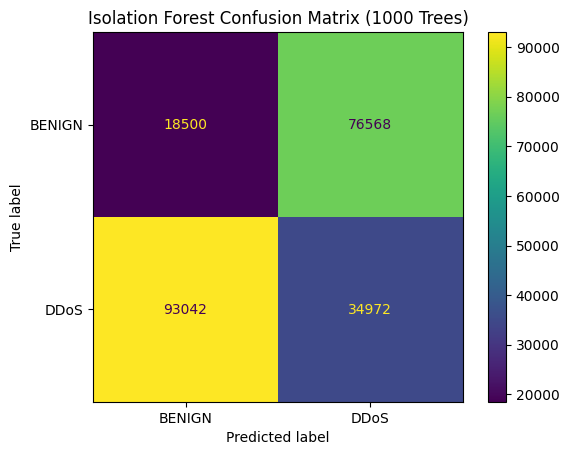

In [35]:
best_iforest = IsolationForest(
    n_estimators=1000,
    contamination=best_contamination,
    random_state=42,
    n_jobs=-1
)

best_iforest.fit(X_scaled)

y_pred = (best_iforest.predict(X_scaled) == -1).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["BENIGN", "DDoS"]
)

plt.title("Isolation Forest Confusion Matrix (1000 Trees)")
plt.savefig(
    "../figures/iforest_best_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

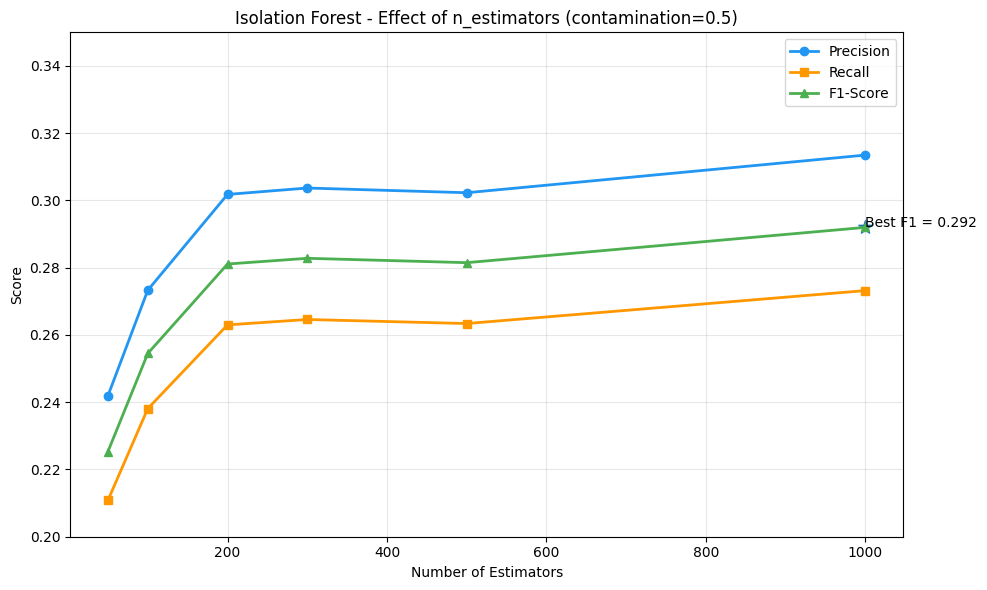

In [36]:
#Visualize n_estimators effect

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(est_df['n_estimators'], est_df['Precision'],
        marker='o', linewidth=2, label='Precision', color='#2196F3')
ax.plot(est_df['n_estimators'], est_df['Recall'],
        marker='s', linewidth=2, label='Recall', color='#FF9800')
ax.plot(est_df['n_estimators'], est_df['F1-Score'],
        marker='^', linewidth=2, label='F1-Score', color='#4CAF50')

ax.set_xlabel('Number of Estimators')
ax.set_ylabel('Score')
ax.set_title(f'Isolation Forest - Effect of n_estimators (contamination={best_contamination})')
ax.legend()
ax.set_ylim(0.20, 0.35)
ax.grid(alpha=0.3)
best_idx = est_df['F1-Score'].idxmax()

ax.scatter(
    est_df.loc[best_idx, 'n_estimators'],
    est_df.loc[best_idx, 'F1-Score'],
    s=100,
    marker='*'
)
ax.annotate(
    f"Best F1 = {est_df['F1-Score'].max():.3f}",
    (
        est_df.loc[best_idx, 'n_estimators'],
        est_df.loc[best_idx, 'F1-Score']
    )
)

plt.tight_layout()
plt.savefig(
    "../figures/iforest_n_estimators_effect.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



## Observation:
 Increasing the number of estimators significantly improved Isolation Forest performance from an F1-score of 0.225 (50 trees) to 0.292 (1000 trees). However, despite this improvement, the model only marginally outperformed the statistical Z-score baseline (F1 = 0.290). This suggests that the selected DDoS dataset does not strongly favor unsupervised anomaly detection methods and may behave more like a binary classification problem than a rare-event anomaly detection scenario.

---

## Anomaly Score Analysis

In [37]:
#Anomaly Score Distribution

anomaly_scores = best_iforest.decision_function(X_scaled)

print("Anomaly Score Statistics:")
print(f"  Min:    {anomaly_scores.min():.4f}")
print(f"  Max:    {anomaly_scores.max():.4f}")
print(f"  Mean:   {anomaly_scores.mean():.4f}")
print(f"  Median: {np.median(anomaly_scores):.4f}")
print(f"  Std:    {anomaly_scores.std():.4f}")

Anomaly Score Statistics:
  Min:    -0.3323
  Max:    0.0406
  Mean:   -0.0226
  Median: 0.0000
  Std:    0.0647


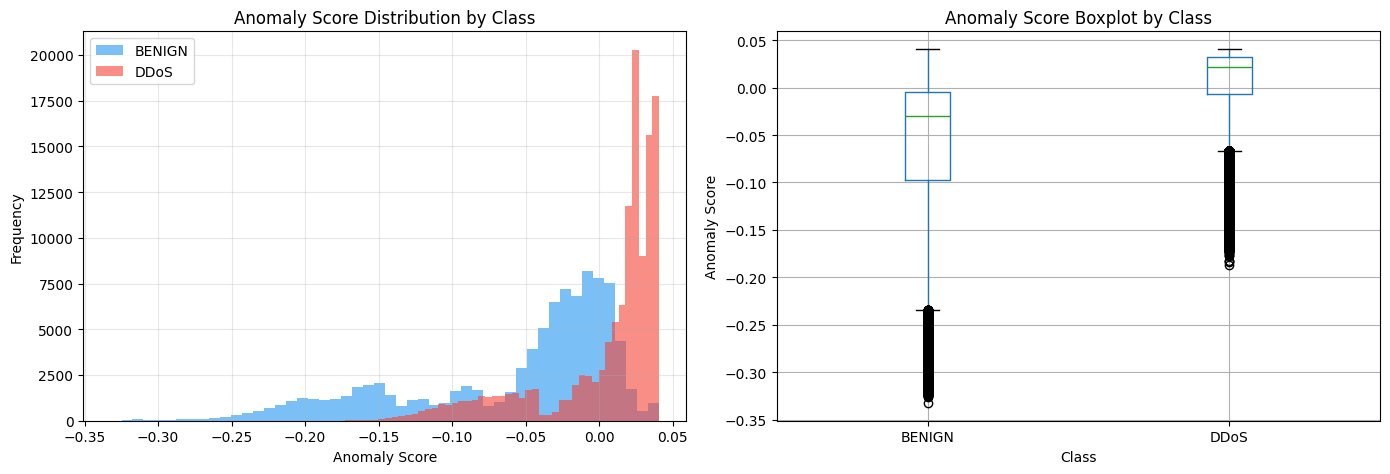

In [38]:
#Anomaly Score Distribution by Class

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(
    anomaly_scores[y_true == 0],
    bins=50, alpha=0.6, label='BENIGN', color='#2196F3'
)
axes[0].hist(
    anomaly_scores[y_true == 1],
    bins=50, alpha=0.6, label='DDoS', color='#F44336'
)
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Anomaly Score Distribution by Class')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
score_df = pd.DataFrame({
    'Anomaly Score': anomaly_scores,
    'Class': ['BENIGN' if y == 0 else 'DDoS' for y in y_true]
})

score_df.boxplot(
    column='Anomaly Score',
    by='Class',
    ax=axes[1]
)
axes[1].set_title('Anomaly Score Boxplot by Class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Anomaly Score')
plt.suptitle('')  # Remove auto-generated title

plt.tight_layout()
plt.savefig(
    "../figures/iforest_anomaly_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Observation:

The anomaly score distribution reveals how well the Isolation Forest separates BENIGN and DDoS traffic. Lower anomaly scores (more negative) indicate more anomalous observations. If there is clear separation between the two distributions, the Isolation Forest is effectively learning the difference between normal and attack traffic. Significant overlap indicates that some DDoS flows resemble normal traffic, making detection challenging.

---

## Feature Importance Analysis

In [39]:
#Feature Importance using Mean Path Length
#
# Isolation Forest does not have a built-in feature_importances_ attribute.
# We approximate feature importance by measuring how much each feature
# contributes to the anomaly score using a permutation-based approach.

from sklearn.inspection import permutation_importance

# Use anomaly score as the target for permutation importance
# We evaluate which features, when shuffled, most change the anomaly scores

best_model_for_importance = best_iforest

# Sample for computational efficiency
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=min(10000, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]
y_sample = y_true.values[sample_idx]

perm_importance = permutation_importance(
    best_model_for_importance,
    X_sample,
    y_sample,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)

feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
}).sort_values('Importance Mean', ascending=False)

print("Top 15 Most Important Features:")
print(importance_df.head(15).to_string(index=False))

print(np.unique(y_true))
print(np.unique(best_model_for_importance.predict(X_sample)))

Top 15 Most Important Features:
                    Feature  Importance Mean  Importance Std
       min_seg_size_forward         0.013512        0.000480
             URG Flag Count         0.012495        0.000749
      Bwd Packet Length Min         0.012377        0.000483
             ACK Flag Count         0.012321        0.000635
           Destination Port         0.011165        0.000599
               Fwd IAT Mean         0.010309        0.000720
          Min Packet Length         0.007839        0.000337
                   Idle Std         0.007414        0.000506
               Flow IAT Std         0.007409        0.000777
Total Length of Fwd Packets         0.006978        0.000372
     Fwd Packet Length Mean         0.006760        0.000199
                   Idle Min         0.006701        0.000514
                  Idle Mean         0.006482        0.000701
              Bwd Packets/s         0.006151        0.000208
              Flow Duration         0.006076        0

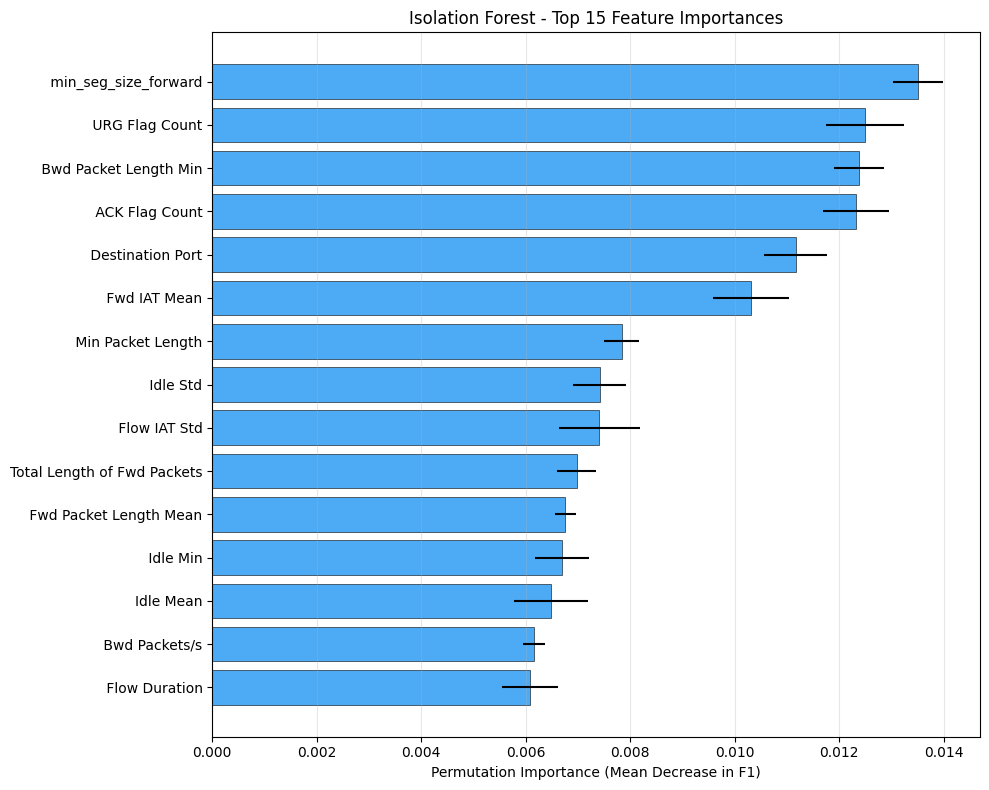

In [40]:
#Feature Importance Visualization (Top 15)
top_n = 15

top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    range(top_n),
    top_features['Importance Mean'].values,
    xerr=top_features['Importance Std'].values,
    color='#2196F3',
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5
)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Permutation Importance (Mean Decrease in F1)')
ax.set_title('Isolation Forest - Top 15 Feature Importances')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../figures/iforest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Observation:

The permutation importance analysis reveals which network flow features are most critical for the Isolation Forest's ability to distinguish DDoS traffic from normal traffic. Features with high importance scores are the ones that, when shuffled, cause the largest drop in detection performance. These features represent the most discriminative characteristics of DDoS attack patterns.

### Next Steps

1. One-Class SVM

2. Extend the analysis to other attack types in the CICIDS2017 dataset.